# Introduction to Data Analysis

In this section, we import essential libraries that will help us explore and analyze the dataset.
- `pandas` for data manipulation.
- `matplotlib` & `seaborn` for data visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's load the **120 Years of Olympic History - Athletes and Results** dataset. Since it's stored online, we use `pd.read_csv()` to read it directly from the URL.

In [2]:
url = "https://raw.githubusercontent.com/cstorm125/information_value/refs/heads/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv"
df = pd.read_csv(url)

Understanding the structure of the dataset is key before diving into analysis. Let's:
- Check the data types of each column.
- Count non-null values.
- Look at the first few rows.

In [3]:
print("Dataset Overview:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 31.0 MB
None

First 5 rows:
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1 

A quick glance at summary statistics helps us understand numerical distributions, potential outliers, and missing values.

In [4]:
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())


Summary Statistics:
                  ID            Age         Height         Weight  \
count  271116.000000  261642.000000  210945.000000  208241.000000   
mean    68248.954396      25.556898     175.338970      70.702393   
std     39022.286345       6.393561      10.518462      14.348020   
min         1.000000      10.000000     127.000000      25.000000   
25%     34643.000000      21.000000     168.000000      60.000000   
50%     68205.000000      24.000000     175.000000      70.000000   
75%    102097.250000      28.000000     183.000000      79.000000   
max    135571.000000      97.000000     226.000000     214.000000   

                Year  
count  271116.000000  
mean     1978.378480  
std        29.877632  
min      1896.000000  
25%      1960.000000  
50%      1988.000000  
75%      2002.000000  
max      2016.000000  

Missing Values:
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC           

Missing values can affect our analysis. Here, we handle missing values in the 'Height' and 'Weight' columns by filling them with the median values.

In [5]:
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

Grouping and counting occurrences of sports helps us understand which events are most frequent in the dataset.

In [6]:
print("\nTop 5 Most Frequent Sports:")
print(df['Sport'].value_counts().head(5))


Top 5 Most Frequent Sports:
Sport
Athletics     38624
Gymnastics    26707
Swimming      23195
Shooting      11448
Cycling       10859
Name: count, dtype: int64


A histogram is a great way to visualize the distribution of ages among Olympic athletes.

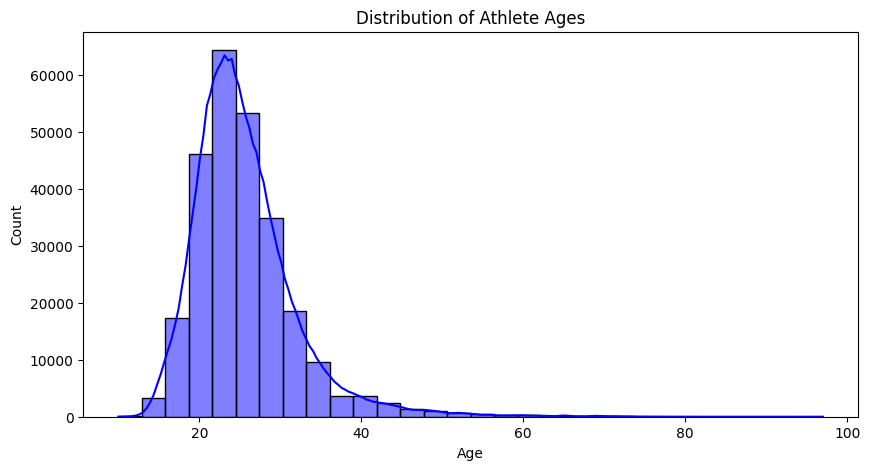

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of Athlete Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

By grouping the data by `Sport` and computing the mean age, we can determine the age distribution across different sports.

In [8]:
sport_ages = df.groupby('Sport')['Age'].mean().sort_values(ascending=False)
print("\nTop 5 Sports by Average Athlete Age:")
print(sport_ages.head(5))


Top 5 Sports by Average Athlete Age:
Sport
Roque               53.333333
Art Competitions    45.901009
Alpinism            38.812500
Polo                35.333333
Equestrianism       34.390831
Name: Age, dtype: float64


A bar chart is useful for comparing the average ages of athletes in different sports.

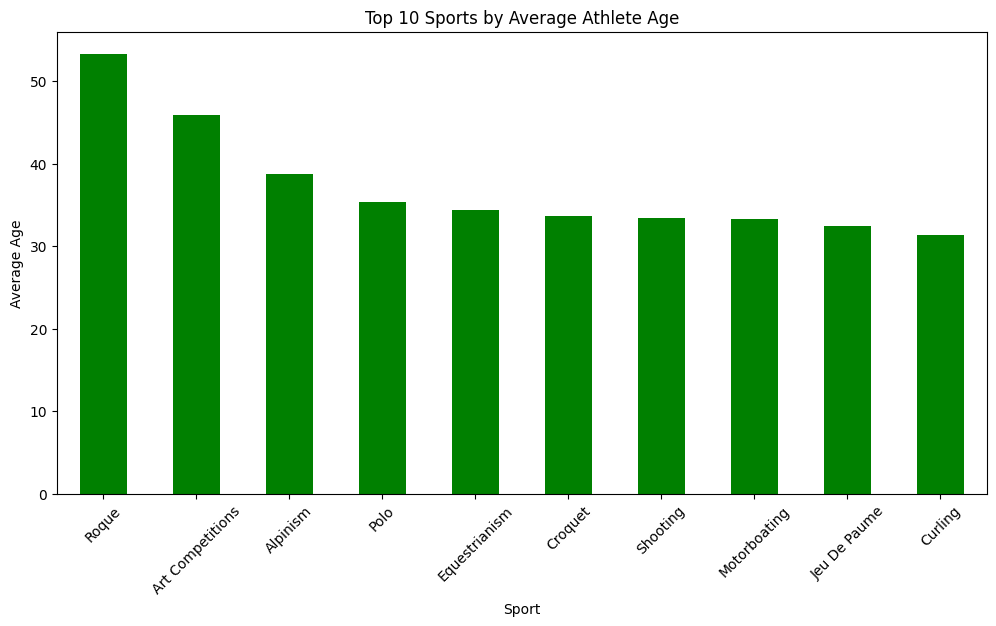

In [9]:
plt.figure(figsize=(12,6))
sport_ages.head(10).plot(kind='bar', color='green')
plt.title('Top 10 Sports by Average Athlete Age')
plt.xlabel('Sport')
plt.ylabel('Average Age')
plt.xticks(rotation=45)
plt.show()

### Most Medalled Male

In [ ]:
males = df[df['Sex'] == 'M']
best_male = males['Name'].value_counts().head(1)
best_male

Name
Robert Tait McKenzie    58
Name: count, dtype: int64

### Most Medalled Female

In [11]:
males = df[df['Sex'] == 'F']
best_male = males['Name'].value_counts().head(1)
best_male

Name
Oksana Aleksandrovna Chusovitina    29
Name: count, dtype: int64

### Romania participations

In [35]:
romania_participations = df[df['Team'] == 'Romania']['Year'].sort_values(ascending= False)
n = 1000
last_n_indices = romania_participations.head(n).index 
last_n_records = df.loc[last_n_indices]

result = df[df['Team'] == 'Romania'].groupby('Sport')['Year'].max().sort_values(ascending=False)

print(result)

Sport
Athletics                    2016
Boxing                       2016
Rowing                       2016
Shooting                     2016
Judo                         2016
Gymnastics                   2016
Handball                     2016
Fencing                      2016
Cycling                      2016
Swimming                     2016
Table Tennis                 2016
Tennis                       2016
Wrestling                    2016
Weightlifting                2016
Rhythmic Gymnastics          2016
Alpine Skiing                2014
Biathlon                     2014
Skeleton                     2014
Ski Jumping                  2014
Figure Skating               2014
Cross Country Skiing         2014
Bobsleigh                    2014
Luge                         2014
Water Polo                   2012
Canoeing                     2012
Freestyle Skiing             2010
Short Track Speed Skating    2010
Diving                       2008
Archery                      2008
Speed Sk